In [1]:
from pathlib import Path
import  sklearn as sk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo path

In [2]:
data_path = r"/content/drive/MyDrive/data/ev_eda_ready.csv" #Path.cwd().parent.parent / "data" / "interim" / "ev_eda_ready.csv"

# Sử lý data

In [3]:
df = pd.read_csv(data_path)

In [4]:
missing_data = df.isnull().sum()
print("Missing data in each column:\n", missing_data)

Missing data in each column:
 id                        0
brand                    27
base_model                0
model_mode                0
year                     67
condition               462
mileage_km              268
has_aftermarket_mods      0
body_type                 0
seats                     0
doors                     0
drivetrain                0
origin                    0
exterior_color          192
city                      0
seller_name               0
post_date                 0
website                   0
price_vnd                 2
dtype: int64


In [5]:
df.dtypes

,0
id,int64
brand,object
base_model,object
model_mode,object
year,float64
condition,object
mileage_km,float64
has_aftermarket_mods,bool
body_type,object
seats,float64


## Fill data trống bằng mean

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Checking if numeric missing values are handled
print("Missing values after mean imputation:")
print(df[numeric_cols].isnull().sum())

Missing values after mean imputation:
id            0
year          0
mileage_km    0
seats         0
doors         0
price_vnd     0
dtype: int64


## Chuyển object sang string

In [7]:
object_cols = df.select_dtypes(include=['object']).columns
df[object_cols] = df[object_cols].astype("string")

# Verify the conversion
print("Data types after conversion:")
display(df.dtypes)

Data types after conversion:


,0
id,int64
brand,string[python]
base_model,string[python]
model_mode,string[python]
year,float64
condition,string[python]
mileage_km,float64
has_aftermarket_mods,bool
body_type,string[python]
seats,float64


In [8]:
# Identify string (object/string) columns
string_cols = df.select_dtypes(include=['string', 'object']).columns

# Print value counts for each string column
for col in string_cols:
    print(f"--- Value counts for '{col}' ---")
    print(df[col].value_counts())
    print("\n")

--- Value counts for 'brand' ---
brand
VinFast          3714
BYD                90
Mercedes-Benz      39
Porsche            22
Bestune            17
Wuling             12
Geely              10
Volvo               9
Ford                8
Hongqi              8
Audi                4
Dongfeng            3
BMW                 2
MINI                2
Hyundai             2
Haima               1
Jaguar              1
Toyota              1
Jaecoo              1
Lexus               1
Name: count, dtype: Int64


--- Value counts for 'base_model' ---
base_model
VF8        851
VF3        770
VF5        632
VF6        424
VF9        327
          ... 
J7 Awd       1
900Lx        1
Mini Ev      1
Lm500H       1
Mvp 7        1
Name: count, Length: 69, dtype: Int64


--- Value counts for 'model_mode' ---
model_mode
VF3                  470
VF5 Plus             429
VF3 Plus             255
VF8 Plus AWD         204
VF6 Plus             191
                    ... 
J7 AWD Individual      1
VF 8S          

## bỏ thành phố, tên ng bán, model của loại xe, năm

In [9]:
# Drop the specified columns
df = df.drop(columns=['city', 'seller_name', 'model_mode', 'year'])

# Display the remaining columns to verify
print("Columns after removal:")
print(df.columns.tolist())

Columns after removal:
['id', 'brand', 'base_model', 'condition', 'mileage_km', 'has_aftermarket_mods', 'body_type', 'seats', 'doors', 'drivetrain', 'origin', 'exterior_color', 'post_date', 'website', 'price_vnd']


## Encode các loại không phải number

In [10]:


# Re-load data or ensure we are working with the correct types
# If columns are already numeric, LabelEncoder won't find them via select_dtypes(include=['string'])

# Let's check for columns that were originally categorical but are now numeric
# Or simply identify the columns we know should be categorical
cat_candidate_cols = ['brand', 'base_model', 'condition', 'body_type', 'drivetrain', 'origin', 'exterior_color', 'website']

le = LabelEncoder()
encoding_mappings = {}

for col in cat_candidate_cols:
    if col in df.columns:
        # Ensure it's treated as string for consistent encoding
        temp_series = df[col].astype(str).fillna('Unknown')
        df[col] = le.fit_transform(temp_series)
        encoding_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print("Categorical columns encoded successfully.")
print("Mappings stored in 'encoding_mappings' dictionary.")
display(df.head())

Categorical columns encoded successfully.
Mappings stored in 'encoding_mappings' dictionary.


,id,brand,base_model,condition,mileage_km,has_aftermarket_mods,body_type,seats,doors,drivetrain,origin,exterior_color,post_date,website,price_vnd
0,0,18,66,2,50000.0,False,4,5.0,5.0,2,0,24,2026-02-28,0,659000000.0
1,1,18,66,1,0.0,False,4,5.0,5.0,7,0,13,2026-02-28,0,790000000.0
2,2,18,66,2,99000.0,False,4,5.0,5.0,2,0,18,2026-02-28,0,599000000.0
3,3,18,66,2,55000.0,False,4,5.0,5.0,2,0,23,2026-02-28,0,580000000.0
4,4,18,63,2,45000.0,False,4,5.0,5.0,7,0,23,2026-02-28,0,399000000.0


### dictionary cho các loại sau khi đổi

In [11]:
print(encoding_mappings)

{'brand': {'<NA>': np.int64(0), 'Audi': np.int64(1), 'BMW': np.int64(2), 'BYD': np.int64(3), 'Bestune': np.int64(4), 'Dongfeng': np.int64(5), 'Ford': np.int64(6), 'Geely': np.int64(7), 'Haima': np.int64(8), 'Hongqi': np.int64(9), 'Hyundai': np.int64(10), 'Jaecoo': np.int64(11), 'Jaguar': np.int64(12), 'Lexus': np.int64(13), 'MINI': np.int64(14), 'Mercedes-Benz': np.int64(15), 'Porsche': np.int64(16), 'Toyota': np.int64(17), 'VinFast': np.int64(18), 'Volvo': np.int64(19), 'Wuling': np.int64(20)}, 'base_model': {'7X-E Premium': np.int64(0), '900Lx': np.int64(1), 'Accent': np.int64(2), 'Atto 2': np.int64(3), 'Atto 3': np.int64(4), 'Atto3 2025': np.int64(5), 'Bingo': np.int64(6), 'Box E2': np.int64(7), 'Box E3': np.int64(8), 'Coolray': np.int64(9), 'Cooper S': np.int64(10), 'Countryman Se-All4': np.int64(11), 'Dolphin': np.int64(12), 'E-Hs9': np.int64(13), 'E-Hs9 Premium': np.int64(14), 'E34': np.int64(15), 'E34 At': np.int64(16), 'E34 Plus': np.int64(17), 'EC Van': np.int64(18), 'EQB 250'

In [12]:
print(df.describe())

                id        brand   base_model    condition    mileage_km  \
count  3974.000000  3974.000000  3974.000000  3974.000000  3.974000e+03   
mean   1991.168596    17.327630    59.975088     1.390287  1.979578e+04   
std    1152.214694     3.034553    11.489723     0.685998  1.216587e+05   
min       0.000000     0.000000     0.000000     0.000000  0.000000e+00   
25%     993.250000    18.000000    62.000000     1.000000  0.000000e+00   
50%    1989.500000    18.000000    63.000000     2.000000  5.000000e+03   
75%    2988.750000    18.000000    66.000000     2.000000  2.500000e+04   
max    3990.000000    20.000000    68.000000     2.000000  7.300000e+06   

         body_type        seats        doors   drivetrain       origin  \
count  3974.000000  3974.000000  3974.000000  3974.000000  3974.000000   
mean      3.477101     5.116256     4.525918     4.892803     2.890539   
std       1.148371     0.913072     0.904004     2.746910     2.518663   
min       0.000000     2.000

# loại outlier và scale lại data

In [13]:
# 1. Loại bỏ Outlier bằng phương pháp IQR
num_features = ['mileage_km', 'seats', 'doors']
Q1 = df[num_features].quantile(0.25)
Q3 = df[num_features].quantile(0.75)
IQR = Q3 - Q1

# Lọc dữ liệu: chỉ giữ lại các dòng nằm trong khoảng (Q1 - 1.5*IQR) và (Q3 + 1.5*IQR)
df_clean = df[~((df[num_features] < (Q1 - 1.5 * IQR)) | (df[num_features] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

print(f"Số lượng dòng sau khi loại bỏ outlier: {len(df_clean)} / {len(df)}")

# 2. Chia lại dữ liệu
X_clean = df_clean.drop(columns=['price_vnd', 'post_date', 'id'])
y_clean = df_clean['price_vnd']

x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# 3. Log Transform target
y_train_log = np.log1p(y_train_c)
y_test_log = np.log1p(y_test_c)

# 4. Scale Features
scaler = StandardScaler()
x_train_scaled = x_train_c.copy()
x_test_scaled = x_test_c.copy()

x_train_scaled[num_features] = scaler.fit_transform(x_train_c[num_features])
x_test_scaled[num_features] = scaler.transform(x_test_c[num_features])

print("Đã hoàn thành loại bỏ outlier và scale data.")

Số lượng dòng sau khi loại bỏ outlier: 2238 / 3974
Đã hoàn thành loại bỏ outlier và scale data.


## chia data 80/20

In [14]:


# Prepare features: convert datetime 'year' to integer to avoid scikit-learn errors
X = df.drop(columns=['price_vnd', 'post_date']).copy()


y = df['price_vnd']

# Split into 80% train and 20% test
x_train_imputed, x_test_imputed, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set shape: {x_train_imputed.shape}")
print(f"Test set shape: {x_test_imputed.shape}")

Train set shape: (3179, 13)
Test set shape: (795, 13)


## tạo grid cho model lasso và ridge, tạo linear regression, lasso, ridge tiêu chuẩn

In [15]:

# Parameter grid for Grid Search
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# 1. Linear Regression
lr = LinearRegression()
lr.fit(x_train_scaled, y_train_log)

# 2. Standard Lasso
lasso_std = Lasso(max_iter=5000)
lasso_std.fit(x_train_scaled, y_train_log)

# 3. Lasso (Grid Search)
gs_lasso = GridSearchCV(Lasso(max_iter=5000), param_grid, cv=5)
gs_lasso.fit(x_train_scaled, y_train_log)

# 4. Standard Ridge
ridge_std = Ridge()
ridge_std.fit(x_train_scaled, y_train_log)

# 5. Ridge (Grid Search)
gs_ridge = GridSearchCV(Ridge(), param_grid, cv=5)
gs_ridge.fit(x_train_scaled, y_train_log)

print(f"Best alpha for Lasso: {gs_lasso.best_params_['alpha']}")
print(f"Best alpha for Ridge: {gs_ridge.best_params_['alpha']}")

models = {
    'Linear': lr,
    'Lasso Standard': lasso_std,
    'Lasso GridSearch': gs_lasso,
    'Ridge Standard': ridge_std,
    'Ridge GridSearch': gs_ridge
}

results = []
for name, model in models.items():
    # Predict in log scale and convert back to original VND scale
    log_preds = model.predict(x_test_scaled)
    preds = np.expm1(log_preds)

    # Use y_test_c (the cleaned version) instead of y_test
    results.append({
        'Model': name,
        'R2': r2_score(y_test_c, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test_c, preds)),
        'MAE': mean_absolute_error(y_test_c, preds)
    })

res_df = pd.DataFrame(results)
display(res_df)

Best alpha for Lasso: 0.001
Best alpha for Ridge: 10


,Model,R2,RMSE,MAE
0,Linear,0.495238,2.060795e+09,1.282147e+09
1,Lasso Standard,0.040211,2.841706e+09,1.880466e+09
2,Lasso GridSearch,0.493989,2.063342e+09,1.283794e+09
3,Ridge Standard,0.495031,2.061216e+09,1.282427e+09
4,Ridge GridSearch,0.493181,2.064989e+09,1.284923e+09


## tạo bảng so sánh

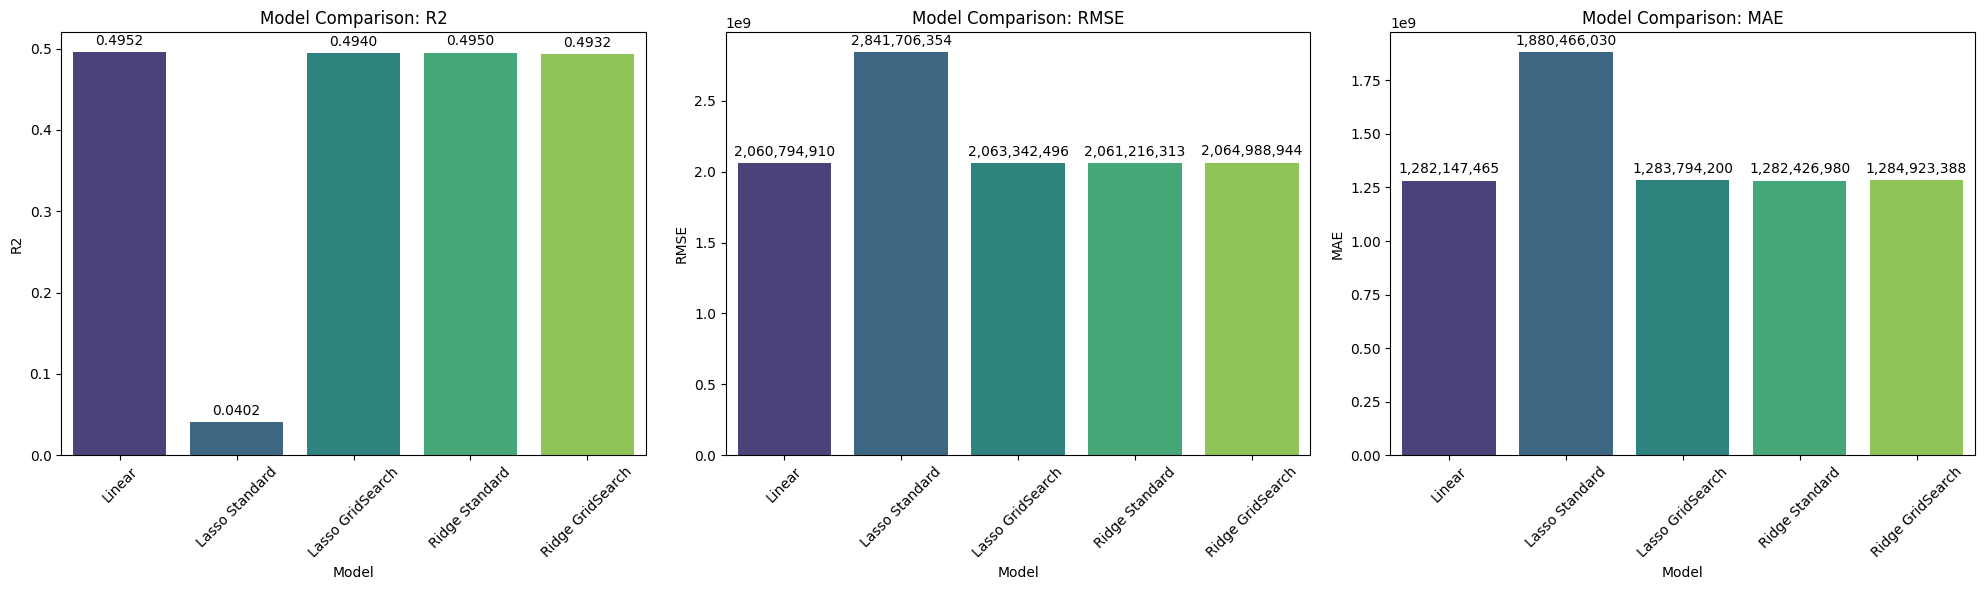

In [16]:
# Melt dataframe for visualization
plot_df = res_df.melt(id_vars='Model', var_name='Metric', value_name='Value')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metrics = ['R2', 'RMSE', 'MAE']

for i, metric in enumerate(metrics):
    sns_plot = sns.barplot(data=res_df, x='Model', y=metric, ax=axes[i], palette='viridis', hue='Model', legend=False)
    axes[i].set_title(f'Model Comparison: {metric}')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

    # Add data labels on top of bars
    for container in axes[i].containers:
        # Use format for R2 as float, and others as comma-separated floats
        label_fmt = '%.4f' if metric == 'R2' else '{:,.0f}'
        if metric == 'R2':
            axes[i].bar_label(container, fmt='%.4f', padding=3)
        else:
            # For RMSE and MAE, manually set the labels to standard currency-style numbering
            labels = [f'{val:,.0f}' for val in container.datavalues]
            axes[i].bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()